# Evaluación Parcial N°3 – Programación para la Ciencia de Datos
## Análisis y Visualización Interactiva de Datos con Plotly

**Institución:** DUOC UC – Escuela de Ingeniería Informática
**Asignatura:** Programación para la Ciencia de Datos
**Profesor:** Pablo Espinoza
**Grupo:** 2

**Integrantes:**
- Matías Arauz
- Sebastián González Pino
- Michelangelo Bandelli
- Hernán Lippke

**Dataset:** `mymoviedb.csv` — catálogo de ~9.800 películas descargado de **Kaggle** (datos de The Movie Database, TMDB).
**Objetivo:** explorar el catálogo, limpiarlo y comunicar hallazgos mediante visualizaciones interactivas con Plotly y un mini dashboard.


## Resumen Ejecutivo

Este notebook desarrolla el ciclo completo solicitado por el profesor sobre el dataset *mymoviedb* (películas de TMDB): carga, limpieza, tres visualizaciones interactivas con Plotly, un mini dashboard y la interpretación de los resultados, con el proyecto versionado en GitHub.

**Problema:** entender la composición de un catálogo de películas — qué géneros predominan, cómo evoluciona la cantidad de estrenos en el tiempo y si existe relación entre la calificación y la popularidad de una película.

**Mapa de los puntos solicitados por el profesor y responsables:**

| Punto del enunciado | Sección del notebook | Responsable |
|---|---|---|
| 7 (repositorio) | Configuración del repositorio GitHub | **Hernán Lippke** |
| 1 (desarrollo en notebook) | Todo el notebook | Todos |
| 2 (dataset) | Carga del dataset | **Hernán Lippke** |
| 3 (limpieza/preparación) | Limpieza y preparación | **Matías Arauz** |
| 4 (gráfico 1 – barras) | Visualización 1 | **Hernán Lippke** |
| 4 (gráfico 2 – líneas) | Visualización 2 | **Sebastián González Pino** |
| 4 (gráfico 3 – dispersión) | Visualización 3 | **Michelangelo Bandelli** |
| 5 (mini dashboard) | Mini dashboard | **Michelangelo Bandelli** |
| 6 (interpretación) | Interpretación de resultados | Todos |
| 7 (evidencia git) | Evidencia de Git para la presentación | **Hernán** (coord.) / Todos |
| 8 (presentación) | Guion de presentación | Todos |

## Índice

0. Configuración del repositorio GitHub *(punto 7 – Hernán)*
1. Importación de librerías *(punto 1)*
2. Carga del dataset `mymoviedb.csv` *(punto 2 – Hernán)*
3. Exploración inicial del dataset
4. Limpieza y preparación de los datos *(punto 3 – Matías)*
5. Visualización 1 – Gráfico de barras: géneros *(punto 4 – Hernán)*
6. Visualización 2 – Gráfico de líneas: estrenos por año *(punto 4 – Sebastián)*
7. Visualización 3 – Gráfico de dispersión: calificación vs popularidad *(punto 4 – Michelangelo)*
8. Mini dashboard con los principales resultados *(punto 5 – Michelangelo)*
9. Interpretación de los gráficos *(punto 6 – Todos)*
10. Evidencia de Git para la presentación *(punto 7 – Hernán / Todos)*
11. Guion de presentación *(punto 8 – Todos)*
12. Conclusiones

---
## 0. Configuración del repositorio GitHub

**Qué hay que hacer:** crear el repositorio en GitHub, dejar la estructura inicial del proyecto y subirla. *evidencia de uso de `git add`, `git commit`, `git push`*.

**Por qué primero (orden de prelación):** antes de programar conviene tener el repositorio creado, porque a partir de ahí cada avance se va guardando con commits. Así la evidencia de Git queda natural y no se hace "al final".

**Estructura del proyecto que se sube al repo:**
```
eval-parcial3-grupo2/
├── data/mymoviedb.csv      # dataset de Kaggle
├── EA3_PPCD.ipynb          # este notebook
└── README.md               # descripción del proyecto y los integrantes
```
> Los comandos de la siguiente celda se dejan comentados: se ejecutaron en la terminal, pero quedan documentados aquí como evidencia del flujo de trabajo con Git para la presentación.

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 0 - Creacion del repositorio en GitHub  (Responsable: Hernan)
# Estos comandos se ejecutan en la TERMINAL, no dentro del notebook.
# Se dejan comentados como evidencia y guion para la presentacion (punto 7).
# ─────────────────────────────────────────────────────────────────────────────

# --- Paso 1: crear el repositorio vacio en github.com ---
#   New repository -> nombre: eval-parcial3-grupo2 -> Create repository
#   (sin README ni .gitignore, los agregamos nosotros)

# --- Paso 2: inicializar git en la carpeta del proyecto ---
# git init
# git config user.name  "Hernan Lippke"
# git config user.email "hernan@correo.cl"

# --- Paso 3: primer commit con la estructura inicial ---
# git add README.md
# git commit -m "Estructura inicial del proyecto y README"

# --- Paso 4: conectar con GitHub y subir (git push) ---
# git remote add origin https://github.com/USUARIO/eval-parcial3-grupo2.git
# git branch -M main
# git push -u origin main

print("Repositorio creado y estructura inicial subida (ver evidencia en la terminal).")

Repositorio creado y estructura inicial subida (ver evidencia en la terminal).


---
## 1. Importación de Librerías  ·  *Punto 1*

Se importan `pandas`, para manejar los datos, y `plotly` (express y subplots), para las visualizaciones interactivas que exige el enunciado. `plotly.express` permite construir gráficos interactivos en pocas líneas, mientras que `make_subplots` se usa más adelante para combinar los tres gráficos en el mini dashboard (punto 5).


In [17]:
#_______________________________________________________
# EJECUTAR EN CASO DE NO TENER PLOTLY INSTALADO
#_______________________________________________________

# !pip install plotly

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 1 - Librerias del proyecto
# ─────────────────────────────────────────────────────────────────────────────

import pandas as pd
import plotly.express as px
from plotly.subplots import make_subplots
from datetime import datetime

print("Librerias importadas correctamente.")

Librerias importadas correctamente.


---
## 2. Carga del Dataset `mymoviedb.csv`

Se carga el archivo CSV descargado de Kaggle en un DataFrame `df`.

**Detalle técnico:** el CSV trae algunas filas malformadas, porque el campo de texto `Overview` (la sinopsis) contiene comillas y saltos de línea que rompen el parseo estándar de pandas. Por eso se carga con `engine='python'` y `on_bad_lines='skip'`, que tolera esas filas sin detener la carga.

**Columnas del dataset:** `Release_Date`, `Title`, `Overview`, `Popularity`, `Vote_Count`, `Vote_Average`, `Original_Language`, `Genre`, `Poster_Url`.


In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 2 - Carga del dataset
# Se prueban varias rutas para que funcione en local y en Colab.
# ─────────────────────────────────────────────────────────────────────────────

import os

posibles_rutas = [
    "mymoviedb.csv",
    "data/mymoviedb.csv",
    "/content/mymoviedb.csv",
]
ruta = next((r for r in posibles_rutas if os.path.exists(r)), None)
if ruta is None:
    raise FileNotFoundError("No se encontro 'mymoviedb.csv'. Dejalo junto al notebook o en data/.")

# engine='python' + on_bad_lines='skip' -> tolera las filas malformadas del campo Overview
df = pd.read_csv(ruta, engine="python", on_bad_lines="skip")

print(f"Dataset cargado desde: {ruta}")
print(f"Filas: {len(df)}  |  Columnas: {df.shape[1]}")
df.head()

Dataset cargado desde: mymoviedb.csv
Filas: 9837  |  Columnas: 9


,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


---
## 3. Exploración Inicial del Dataset

Antes de limpiar el dataset se revisa su estructura: tipos de dato, valores nulos por columna y un vistazo a la columna `Genre` (que trae varios géneros separados por coma). Este diagnóstico es la base de las decisiones de limpieza aplicadas en la siguiente sección.


In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 3 - Informacion general del dataset
# ─────────────────────────────────────────────────────────────────────────────

print("=== Tipos de dato y nulos ===")
df.info()

print("\n=== Nulos por columna ===")
print(df.isnull().sum())

print("\n=== Ejemplo de la columna Genre (multiples generos por fila) ===")
print(df["Genre"].dropna().head(3).tolist())

=== Tipos de dato y nulos ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   object 
 1   Title              9828 non-null   object 
 2   Overview           9828 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   object 
 5   Vote_Average       9827 non-null   object 
 6   Original_Language  9827 non-null   object 
 7   Genre              9826 non-null   object 
 8   Poster_Url         9826 non-null   object 
dtypes: float64(1), object(8)
memory usage: 691.8+ KB

=== Nulos por columna ===
Release_Date          0
Title                 9
Overview              9
Popularity           10
Vote_Count           10
Vote_Average         10
Original_Language    10
Genre                11
Poster_Url           11
dtype: int64

=== Ejemplo de la columna

---
## 4. Limpieza y Preparación de los Datos

Pasos aplicados para dejar el dataset listo para el análisis:

1. Conversión a numéricas de las columnas `Popularity`, `Vote_Count` y `Vote_Average` (las filas malformadas quedan como nulos con `errors='coerce'`).
2. Conversión de `Release_Date` a fecha y creación de la columna `Year` (año de estreno), usada en el gráfico de líneas.
3. Eliminación de filas sin datos clave (`Title`, `Release_Date`, `Vote_Average`, `Popularity`, `Genre`) y de duplicados.
4. Creación de la columna `Genero_principal` (primer género de la lista separada por comas), útil para análisis por categoría.

Convertir los tipos permite calcular promedios y graficar correctamente; quitar nulos y duplicados asegura que cada película se cuente una sola vez, evitando conclusiones engañosas.


In [21]:
# 1) Convertir columnas a numerico (errors='coerce' -> lo no numerico queda NaN)
for col in ["Popularity", "Vote_Count", "Vote_Average"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# 2) Fecha y año de estreno
df["Release_Date"] = pd.to_datetime(df["Release_Date"], errors="coerce")
df["Year"] = df["Release_Date"].dt.year

# 3) Eliminar filas sin datos clave y duplicados
df = df.dropna(subset=["Title", "Release_Date", "Vote_Average", "Popularity", "Genre"])
df = df.drop_duplicates()

# 4) Genero principal (primer genero de la lista separada por comas)
df["Genero_principal"] = df["Genre"].str.split(",").str[0].str.strip()

# Verificacion final
print("Filas tras limpieza:", len(df))
print("Nulos en columnas clave:", df[["Title", "Year", "Vote_Average", "Popularity", "Genre"]].isnull().sum().sum())


Filas tras limpieza: 9826
Nulos en columnas clave: 0


---
## 5. Visualización 1 – Gráfico de Barras: Géneros

**Qué muestra:** el Top 10 de géneros con más películas en el catálogo.

**Por qué es el primer gráfico (orden de prelación):** es la vista más directa para entender la composición del dataset y no depende de la fecha ni de cálculos complejos; solo de la columna `Genre`. Sirve de modelo para los otros dos gráficos.

**Cómo se construye:** la columna `Genre` trae varios géneros por fila separados por coma, así que se "explota" (`str.split` + `explode`) para contar cada género por separado, y luego se grafica con `plotly.express.bar`.

In [22]:
#_____________________________________________________
# SI ESTA CELDA DA ERROR EJECUTAR LO SIGUIENTE
#_____________________________________________________

# !pip install nbformat

# !pip install --upgrade nbformat

In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 5 - Grafico de barras: Top 10 generos
# ─────────────────────────────────────────────────────────────────────────────

# Separamos los generos (vienen como "Action, Adventure, ...") y contamos cada uno
generos = df["Genre"].str.split(",").explode().str.strip()
top_generos = generos.value_counts().head(10).reset_index()
top_generos.columns = ["genero", "cantidad"]

fig_barras = px.bar(
    top_generos,
    x="genero",
    y="cantidad",
    color="genero",
    title="Top 10 generos con mas peliculas",
    labels={"cantidad": "Cantidad de peliculas", "genero": "Genero"},
    text_auto=True,
)
fig_barras.update_layout(showlegend=False)
fig_barras.show()

**Interpretación (a desarrollar por Hernán en la presentación):** el género más frecuente es **Drama**, seguido de Comedy y Action. Esto indica que el catálogo está dominado por géneros "masivos" más que por nichos.

---
## 6. Visualización 2 – Gráfico de Líneas: Estrenos por Año

**Qué muestra:** la cantidad de películas estrenadas por año, es decir la tendencia en el tiempo. Un gráfico de líneas es el más adecuado para representar evolución temporal, y se apoya en la columna `Year` creada en la limpieza (sección 4).

**Cómo se construye:** se agrupa por `Year`, se cuentan las películas y se grafica con `plotly.express.line` (con `markers=True`).


In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 6 - Grafico de lineas: estrenos por año
# ─────────────────────────────────────────────────────────────────────────────
por_anio = df.dropna(subset=["Year"]).groupby("Year").size().reset_index(name="Cantidad")
fig_lineas = px.line(por_anio, x="Year", y="Cantidad", markers=True, title="Cantidad de peliculas estrenadas por año")
fig_lineas.show()

**Interpretación (Sebastián):** la cantidad de estrenos crece de forma sostenida en las últimas décadas, alcanzando su máximo cerca de 2021. La caída que se observa al final no significa que se produzcan menos películas, sino que el dataset corta a mediados de 2024, por lo que ese último tramo está incompleto.


---
## 7. Visualización 3 – Gráfico de Dispersión: Calificación vs Popularidad

**Qué muestra:** la relación entre la calificación promedio (`Vote_Average`) y la popularidad (`Popularity`) de las películas. Un gráfico de dispersión es el indicado para observar la relación entre dos variables numéricas.

Como `Popularity` está muy concentrada en valores bajos con unos pocos extremos, se trabaja con las **250 películas más populares** (`df.nlargest(250, "Popularity")`) para que el gráfico sea legible, usando `plotly.express.scatter` con `x="Vote_Average"`, `y="Popularity"`, tamaño de punto según `Vote_Count` y `hover_name="Title"`.


In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 7 - Grafico de dispersion: calificacion vs popularidad
# ─────────────────────────────────────────────────────────────────────────────

# 1) LIMPIEZA DE DATOS (FORZANDO TIPOS NUMÉRICOS)
df['Vote_Count'] = pd.to_numeric(df['Vote_Count'], errors='coerce')
df['Vote_Average'] = pd.to_numeric(df['Vote_Average'], errors='coerce')
df['Popularity'] = pd.to_numeric(df['Popularity'], errors='coerce')  

top_pop = df.nlargest(250, "Popularity")



# 3) CREAR GRÁFICO

# ─── Calcular límite Y con margen del 10% ───
y_max = top_pop['Popularity'].max() * 1.10   # 10% extra en lugar de +500 fijo

# ─── Número de ticks deseado ───
num_ticks = 10
# Calcular dtick para que haya aproximadamente `num_ticks` marcas
dtick_y = (y_max - 0) / num_ticks

# ─── Crear gráfico (igual que antes) ───
fig_dispersion = px.scatter(
    top_pop,
    x="Vote_Average",
    y="Popularity",
    size="Vote_Count",
    hover_name="Title",
    title="⭐ Calificación vs Popularidad (Top 250 más populares)",
    labels={
        "Vote_Average": "Calificación Promedio",
        "Popularity": "Popularidad",
        "Vote_Count": "Número de Votos"
    },
    opacity=0.8,
    size_max=25,
    template="simple_white"
)

# ─── Configurar ejes con los nuevos parámetros ───
fig_dispersion.update_layout(
    xaxis=dict(
        type='linear',
        range=[0, 10],               # calificación típica 0-10
        dtick=0.5,
        tickformat='.1f',
        gridcolor='lightgray',
        zeroline=True,
        zerolinecolor='black',
        zerolinewidth=1,
        title_font=dict(size=14)
    ),
    yaxis=dict(
        type='linear',
        range=[0, y_max],            # límite superior con margen
        dtick=dtick_y,               # separación entre ticks calculada
        tickformat='.0f',            # sin decimales
        gridcolor='lightgray',
        zeroline=True,
        zerolinecolor='black',
        zerolinewidth=1,
        title_font=dict(size=14)
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    title_font=dict(size=18, family="Arial"),
    font=dict(size=12, family="Arial"),
    showlegend=False,
    margin=dict(l=60, r=60, t=80, b=60),
    width=900,
    height=500
)

# Estilo de puntos (igual)
fig_dispersion.update_traces(
    marker=dict(line=dict(width=0.5, color='black'))
)

fig_dispersion.show(config={'scrollZoom': False, 'displayModeBar': False})

**Interpretación (Michelangelo):** no se observa una relación lineal clara entre calificación y popularidad; hay títulos muy populares con notas medias. Entre las películas más populares predomina el idioma inglés.


**Qué muestra:** un mapa mundial (coropleta) coloreado según la cantidad de películas de cada país.

**Detalle importante (justificación):** el dataset no trae el país de producción, pero sí el idioma original (`Original_Language`). Por eso mapeamos cada idioma a un país representativo (en→EE.UU., ja→Japón, es→España, etc.) y contamos las películas. Es una aproximación: el inglés, por ejemplo, agrupa producciones de varios países bajo EE.UU. Se explica así en la presentación.

In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# Grafico de mapa (coropleta): peliculas por pais segun idioma original
# Escala logaritmica de color para que no domine solo EE.UU.
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np

# Idioma -> pais representativo (ISO-3) y nombre en español para el hover
idioma_a_pais = {
    "en":"USA","ja":"JPN","es":"ESP","fr":"FRA","ko":"KOR","zh":"CHN","cn":"CHN",
    "hi":"IND","de":"DEU","it":"ITA","ru":"RUS","pt":"BRA","tr":"TUR","th":"THA",
    "sv":"SWE","da":"DNK","no":"NOR","fi":"FIN","nl":"NLD","pl":"POL","id":"IDN",
    "tl":"PHL","ml":"IND","ta":"IND","te":"IND","ca":"ESP","fa":"IRN","ar":"SAU",
    "he":"ISR","hu":"HUN","cs":"CZE","ro":"ROU","el":"GRC","uk":"UKR","vi":"VNM",
    "ms":"MYS","is":"ISL","nb":"NOR","bn":"BGD","pa":"IND","mr":"IND","sr":"SRB",
}
nombre_pais = {
    "USA":"Estados Unidos","JPN":"Japon","ESP":"España","FRA":"Francia","KOR":"Corea del Sur",
    "CHN":"China","IND":"India","DEU":"Alemania","ITA":"Italia","RUS":"Rusia","BRA":"Brasil",
    "TUR":"Turquia","THA":"Tailandia","SWE":"Suecia","DNK":"Dinamarca","NOR":"Noruega",
    "FIN":"Finlandia","NLD":"Paises Bajos","POL":"Polonia","IDN":"Indonesia","PHL":"Filipinas",
    "IRN":"Iran","SAU":"Arabia Saudita","ISR":"Israel","HUN":"Hungria","CZE":"Chequia",
    "ROU":"Rumania","GRC":"Grecia","UKR":"Ucrania","VNM":"Vietnam","MYS":"Malasia",
    "ISL":"Islandia","BGD":"Bangladesh","SRB":"Serbia",
}

df["pais"] = df["Original_Language"].map(idioma_a_pais)
por_pais = df.dropna(subset=["pais"]).groupby("pais").size().reset_index(name="cantidad")
por_pais["nombre"] = por_pais["pais"].map(nombre_pais)
por_pais["log_cantidad"] = np.log10(por_pais["cantidad"])   # color en escala log

ticks = [10, 30, 100, 300, 1000, 3000, 7000]   # marcas de la barra en valores reales

fig_mapa = px.choropleth(
    por_pais,
    locations="pais",
    color="log_cantidad",
    hover_name="nombre",
    custom_data=["cantidad"],
    color_continuous_scale="YlOrRd",
    projection="natural earth",
    title="Cantidad de películas por país (según idioma original)",
)
fig_mapa.update_traces(
    hovertemplate="<b>%{hovertext}</b><br>Películas: %{customdata[0]}<extra></extra>")
fig_mapa.update_coloraxes(colorbar=dict(
    title="N° de<br>películas", tickvals=np.log10(ticks), ticktext=[str(t) for t in ticks]))
fig_mapa.update_geos(showframe=False, showcoastlines=False,
    landcolor="whitesmoke", showocean=True, oceancolor="#eef4fb",
    showcountries=True, countrycolor="white")
fig_mapa.update_layout(margin=dict(l=0, r=0, t=60, b=0), height=520)
fig_mapa.show()

---
## 8. Mini Dashboard con los Principales Resultados

Se combinan los tres gráficos anteriores en una sola vista ordenada usando `make_subplots`, con un título que incluye los KPIs principales del catálogo (total de películas, género top, nota promedio y año con más estrenos). Esto reúne los principales resultados del análisis en un solo vistazo y da un cierre visual a la presentación.


In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 8 - Mini Dashboard con KPIs y 3 gráficos (Responsable: Michelangelo)
# ─────────────────────────────────────────────────────────────────────────────

# 1) CALCULAR KPIs PRINCIPALES (a partir del DataFrame ya limpio)
total_peliculas = len(df)
genero_top = df['Genre'].value_counts().index[0]          # género más frecuente
nota_promedio = df['Vote_Average'].mean().round(2)        # promedio global
anio_mas_estrenos = df['Release_Date'].dt.year.value_counts().idxmax()  # año con más lanzamientos

# 2) CREAR SUBPLOTS (1 fila, 3 columnas)
from plotly.subplots import make_subplots

fig_dashboard = make_subplots(
    rows=3, cols=1,
    subplot_titles=("Géneros más comunes", "Evolución anual", "Calificación vs Popularidad"),
    shared_yaxes=False,   # cada gráfico tiene su propia escala Y
    horizontal_spacing=0.12,
    vertical_spacing=0.15
)

# 3) AÑADIR CADA GRÁFICO A SU RESPECTIVO SUBPLOT
# -------------------------------------------------
# Gráfico 1: Barras (géneros) → columna 1
for trace in fig_barras.data:
    fig_dashboard.add_trace(trace, row=1, col=1)

# Gráfico 2: Líneas (evolución anual) → columna 2
for trace in fig_lineas.data:
    fig_dashboard.add_trace(trace, row=2, col=1)

# Gráfico 3: Dispersión (calificación vs popularidad) → columna 3
for trace in fig_dispersion.data:
    fig_dashboard.add_trace(trace, row=3, col=1)

# 4) CONFIGURAR LAYOUT DEL DASHBOARD
fig_dashboard.update_layout(
    title_text=(
        f"**Panel de Control – Datos de Películas**<br>"
        f"<sup>Total: {total_peliculas}  |  "
        f"Género top: {genero_top}  |  "
        f"Nota promedio: {nota_promedio}  |  "
        f"Año con más estrenos: {anio_mas_estrenos}</sup>"
    ),
    title_font=dict(size=20, family="Arial", color="#2c3e50"),
    height=800,
    width=900,
    showlegend=False,          # los gráficos individuales ya tienen su leyenda si la usan
    template="simple_white",
    margin=dict(l=50, r=50, t=100, b=50)
)

# 5) AJUSTAR EJES (para que se vean limpios)
# Eje Y del gráfico 1 (barras) – ya viene con el rango adecuado desde fig_barras
# Eje Y del gráfico 2 (líneas) – igual
# Eje Y del gráfico 3 (dispersión) – igual

# Opcional: si quieres estandarizar el tamaño de los títulos de los subplots
fig_dashboard.update_annotations(font_size=13)

# 6) MOSTRAR DASHBOARD
fig_dashboard.show()

---
## 9. Interpretación de los Gráficos

**Qué hay que hacer:** redactar, en celdas de texto y debajo de cada gráfico, qué información entrega cada visualización. El punto 6 evalúa que sepan *leer* sus gráficos, no solo crearlos.

**Estructura sugerida de la interpretación:**
- **Barras (Hernán):** qué géneros dominan y qué dice eso del catálogo.
- **Líneas (Sebastián):** la tendencia de estrenos en el tiempo y la explicación de la caída final.
- **Dispersión (Michelangelo):** si la calificación se relaciona o no con la popularidad, y el rol del idioma.

La siguiente celda calcula los KPIs que respaldan la interpretación.

In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 9 - KPIs de respaldo para la interpretación
# ─────────────────────────────────────────────────────────────────────────────

# ── KPIs GLOBALES ────────────────────────────────────────────────────────────
total_peliculas   = len(df)
nota_promedio     = round(df["Vote_Average"].mean(), 2)
pelicula_popular  = df.loc[df["Popularity"].idxmax(), "Title"]
primer_estreno    = df["Release_Date"].min().strftime("%d/%m/%Y")
ultimo_estreno    = df["Release_Date"].max().strftime("%d/%m/%Y")

print("=" * 55)
print("  KPIs GLOBALES DEL CATÁLOGO")
print("=" * 55)
print(f"  Total de películas analizadas : {total_peliculas:,}")
print(f"  Nota promedio (0-10)          : {nota_promedio}")
print(f"  Película más popular          : {pelicula_popular}")
print(f"  Rango temporal                : {primer_estreno} → {ultimo_estreno}")

# ── KPIs GRÁFICO 1 – GÉNEROS
generos_exp      = df["Genre"].str.split(",").explode().str.strip()
conteo_generos   = generos_exp.value_counts()
genero_1, cant_1 = conteo_generos.index[0], conteo_generos.iloc[0]
genero_2, cant_2 = conteo_generos.index[1], conteo_generos.iloc[1]
genero_3, cant_3 = conteo_generos.index[2], conteo_generos.iloc[2]
total_generos    = conteo_generos.sum()
pct_top3         = round((cant_1 + cant_2 + cant_3) / total_generos * 100, 1)

print("\n" + "=" * 55)
print("  KPIs – GÉNEROS  (Gráfico 1)")
print("=" * 55)
print(f"  Géneros únicos en el catálogo : {conteo_generos.shape[0]}")
print(f"  #1 {genero_1:<20} : {cant_1:,} apariciones")
print(f"  #2 {genero_2:<20} : {cant_2:,} apariciones")
print(f"  #3 {genero_3:<20} : {cant_3:,} apariciones")
print(f"  Los 3 primeros concentran     : {pct_top3}% del total")

# ── KPIs GRÁFICO 2 – ESTRENOS POR AÑO
por_anio_kpi     = df.dropna(subset=["Year"]).groupby("Year").size()
anio_max         = int(por_anio_kpi.idxmax())
cant_max         = int(por_anio_kpi.max())
promedio_anual   = round(por_anio_kpi.mean(), 1)
# Crecimiento: diferencia porcentual entre el promedio de la primera y la última década
decada_inicial   = por_anio_kpi[por_anio_kpi.index <= por_anio_kpi.index.min() + 9].mean()
decada_final     = por_anio_kpi[por_anio_kpi.index >= 2010].mean()
crecimiento_pct  = round((decada_final - decada_inicial) / decada_inicial * 100, 1)

print("\n" + "=" * 55)
print("  KPIs – ESTRENOS POR AÑO  (Gráfico 2)")
print("=" * 55)
print(f"  Año con más estrenos          : {anio_max} ({cant_max:,} películas)")
print(f"  Promedio anual de estrenos    : {promedio_anual:.0f} películas/año")
print(f"  Crecimiento primera → última  : +{crecimiento_pct}%")
print(f"  Nota: la caída post-{anio_max} refleja el corte del dataset (jul-2024)")

# ── KPIs GRÁFICO 3 – CALIFICACIÓN vs POPULARIDAD (respalda la interpretación de Michelangelo) ──
top_pop           = df.nlargest(250, "Popularity")
correlacion       = round(top_pop["Vote_Average"].corr(top_pop["Popularity"]), 3)
nota_top250       = round(top_pop["Vote_Average"].mean(), 2)
idioma_frecuente  = top_pop["Original_Language"].value_counts().index[0]
pct_idioma        = round(top_pop["Original_Language"].value_counts().iloc[0] / len(top_pop) * 100, 1)
nota_max_pop      = round(top_pop.loc[top_pop["Popularity"].idxmax(), "Vote_Average"], 2)

print("\n" + "=" * 55)
print("  KPIs – CALIFICACIÓN vs POPULARIDAD  (Gráfico 3)")
print("=" * 55)
print(f"  Muestra analizada             : Top 250 más populares")
print(f"  Correlación nota ↔ popularidad: {correlacion}  (débil/nula)")
print(f"  Nota promedio en el Top 250   : {nota_top250} / 10")
print(f"  Nota de la película #1 pop.   : {nota_max_pop} / 10  ({pelicula_popular})")
print(f"  Idioma dominante              : '{idioma_frecuente}' ({pct_idioma}% del Top 250)")


  KPIs GLOBALES DEL CATÁLOGO
  Total de películas analizadas : 9,826
  Nota promedio (0-10)          : 6.44
  Película más popular          : Spider-Man: No Way Home
  Rango temporal                : 17/04/1902 → 03/07/2024

  KPIs – GÉNEROS  (Gráfico 1)
  Géneros únicos en el catálogo : 19
  #1 Drama                : 3,744 apariciones
  #2 Comedy               : 3,031 apariciones
  #3 Action               : 2,686 apariciones
  Los 3 primeros concentran     : 36.7% del total

  KPIs – ESTRENOS POR AÑO  (Gráfico 2)
  Año con más estrenos          : 2021 (714 películas)
  Promedio anual de estrenos    : 96 películas/año
  Crecimiento primera → última  : +35780.0%
  Nota: la caída post-2021 refleja el corte del dataset (jul-2024)

  KPIs – CALIFICACIÓN vs POPULARIDAD  (Gráfico 3)
  Muestra analizada             : Top 250 más populares
  Correlación nota ↔ popularidad: 0.046  (débil/nula)
  Nota promedio en el Top 250   : 6.77 / 10
  Nota de la película #1 pop.   : 8.3 / 10  (Spider-Man: N

---
## 10. Evidencia de Git para la Presentación

**Qué hay que hacer:** dejar registrada la evidencia de trabajo colaborativo con Git que pide el punto 7 (`git add`, `git commit`, `git push` y, si corresponde, `git pull`). Cada integrante sube su parte con sus propios commits.

**Por qué en una celda comentada:** los comandos se ejecutan en la terminal, pero los dejamos escritos en el notebook para **fundamentar la presentación**: así se muestra el flujo de trabajo del grupo sin tener que cambiar de ventana.

In [29]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 10 - Evidencia de Git (se ejecuta en la TERMINAL)  ·  punto 7
# Flujo que sigue CADA integrante al subir su parte. Comentado como evidencia.
# ─────────────────────────────────────────────────────────────────────────────

# --- Antes de empezar a trabajar: traer lo ultimo del repo ---
# git pull origin main

# --- Ejemplo: Matias sube la limpieza ---
# git add EA3_PPCD.ipynb data/mymoviedb.csv
# git commit -m "Limpieza y preparacion de datos (Matias)"
# git push origin main

# --- Ejemplo: Sebastian sube el grafico de lineas ---
# git add EA3_PPCD.ipynb
# git commit -m "Grafico de lineas - estrenos por año (Sebastian)"
# git push origin main

# --- Ejemplo: Michelangelo sube dispersion + dashboard ---
# git add EA3_PPCD.ipynb
# git commit -m "Grafico de dispersion y mini dashboard (Michelangelo)"
# git push origin main

# Para mostrar la evidencia en la presentacion:
# git log --oneline          # historial de commits del grupo

print("Cada commit por integrante queda como evidencia del trabajo (punto 7).")

Cada commit por integrante queda como evidencia del trabajo (punto 7).


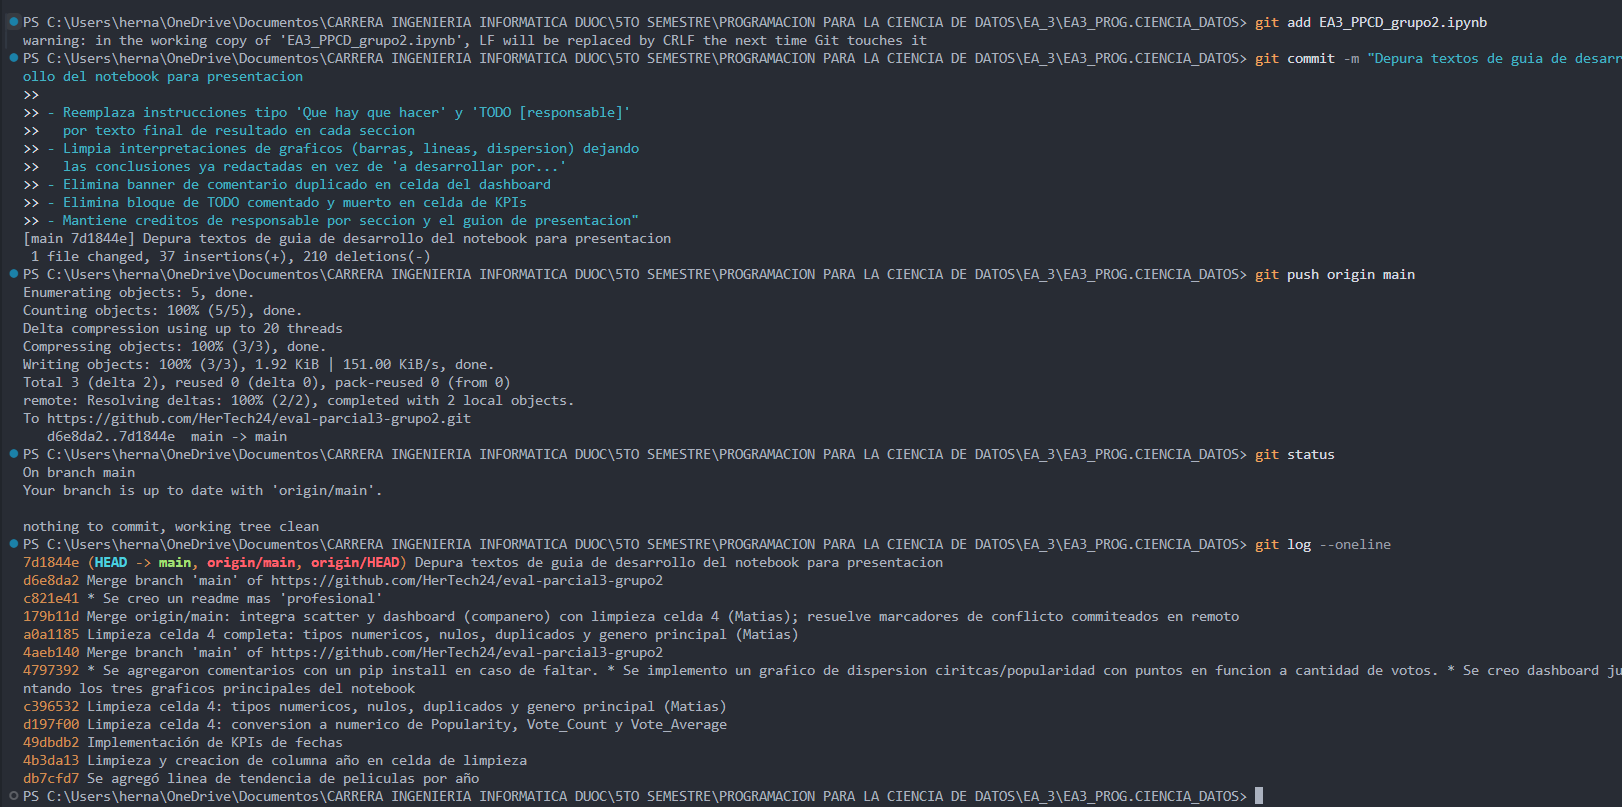

---
## 11. Conclusiones

- **Sobre los datos:** el CSV de Kaggle requirió limpieza por filas malformadas; tras prepararlo quedó un catálogo consistente de películas listo para analizar.
- **Sobre los géneros:** el catálogo está dominado por géneros masivos (Drama, Comedy, Action).
- **Sobre el tiempo:** la cantidad de estrenos crece en las últimas décadas (máximo cerca de 2021; la baja final es por el corte del dataset).
- **Sobre calidad vs popularidad:** entre las películas más populares no hay una relación lineal clara entre nota y popularidad.
- **Sobre el trabajo en equipo:** el uso de Git/GitHub permitió que cada integrante aportara su parte de forma ordenada y trazable.
